# Replenishment Analysis

This notebook translates the final 15-day demand forecast into replenishment recommendations.

Because the original dataset does not contain inventory levels, the replenishment calculation is based on explicit assumptions for lead time, safety stock, and current stock.

In [13]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
project_root = Path("..").resolve()

predictions_path = project_root / "predictions"
outputs_path = project_root / "outputs"

print("Project root:", project_root)

Project root: D:\retail-demand-forecasting


## 1. Load Final Forecast

The final DeepAR forecast contains the predicted demand for the 15-day forecast horizon across the supported Store × Family series.

In [4]:
forecast_df = pd.read_parquet(
    predictions_path / "final_deepar_forecast.parquet"
)

forecast_df["date"] = pd.to_datetime(forecast_df["date"])

print("Forecast shape:", forecast_df.shape)
print("First date:", forecast_df["date"].min())
print("Last date:", forecast_df["date"].max())
print(
    "Unique series:",
    forecast_df[["store_nbr", "family"]].drop_duplicates().shape[0]
)

Forecast shape: (25920, 4)
First date: 2017-08-16 00:00:00
Last date: 2017-08-30 00:00:00
Unique series: 1728


## 2. Forecast Summary

The forecast is aggregated across the 15-day horizon to estimate the expected demand for each Store × Family series.

In [5]:
forecast_summary = (
    forecast_df
    .groupby(["store_nbr", "family"], as_index=False)
    .agg(
        forecast_demand=("deepar_pred", "sum"),
        average_daily_demand=("deepar_pred", "mean"),
        max_daily_demand=("deepar_pred", "max")
    )
)

print("Forecast summary shape:", forecast_summary.shape)
print("Unique series:", forecast_summary[["store_nbr", "family"]].drop_duplicates().shape[0])

forecast_summary.head()

Forecast summary shape: (1728, 5)
Unique series: 1728


,store_nbr,family,forecast_demand,average_daily_demand,max_daily_demand
0,1,AUTOMOTIVE,30.804455,2.053630,2.513572
1,1,BEAUTY,0.452888,0.030193,0.086909
2,1,BEVERAGES,29.505627,1.967042,2.593776
3,1,BOOKS,21088.132812,1405.875488,1677.333496
4,1,BREAD/BAKERY,1491.301514,99.420097,119.986595


## 3. Replenishment Assumptions

The original dataset does not contain inventory levels or supplier lead times.

Therefore, the replenishment analysis uses explicit assumptions:
- Lead time: 3 days
- Safety stock: 20% of expected lead-time demand
- Current stock: assumed to be provided as an input in deployment

These assumptions are used only to demonstrate the replenishment logic and can be adjusted for real operational settings.

In [6]:
LEAD_TIME_DAYS = 3
SAFETY_STOCK_RATE = 0.20

forecast_summary["lead_time_demand"] = (
    forecast_summary["average_daily_demand"] * LEAD_TIME_DAYS
)

forecast_summary["safety_stock"] = (
    forecast_summary["lead_time_demand"] * SAFETY_STOCK_RATE
)

print("Lead time:", LEAD_TIME_DAYS, "days")
print("Safety stock rate:", SAFETY_STOCK_RATE)

Lead time: 3 days
Safety stock rate: 0.2


## 4. Recommended Order Quantity

The recommended order quantity is based on expected demand during the lead time plus safety stock.

Since current inventory is not available in the dataset, the recommendation represents the required replenishment quantity before accounting for actual on-hand stock.

In [ ]:
forecast_summary["recommended_order_qty"] = (
    forecast_summary["lead_time_demand"]
    + forecast_summary["safety_stock"]
)

forecast_summary["recommended_order_qty"] = (
    forecast_summary["recommended_order_qty"].clip(lower=0).round()
)

print(
    "Total recommended replenishment:",
    forecast_summary["recommended_order_qty"].sum()
)

forecast_summary[
    [
        "store_nbr",
        "family",
        "forecast_demand",
        "lead_time_demand",
        "safety_stock",
        "recommended_order_qty",
    ]
].head()

Total recommended replenishment: 2703027.0


,store_nbr,family,forecast_demand,lead_time_demand,safety_stock,recommended_order_qty
0,1,AUTOMOTIVE,30.804455,6.160891,1.232178,7.0
1,1,BEAUTY,0.452888,0.090578,0.018116,0.0
2,1,BEVERAGES,29.505627,5.901125,1.180225,7.0
3,1,BOOKS,21088.132812,4217.626465,843.525330,5061.0
4,1,BREAD/BAKERY,1491.301514,298.260284,59.652058,358.0
...,...,...,...,...,...,...
1723,9,POULTRY,6442.683594,1288.536743,257.707367,1546.0
1724,9,PREPARED FOODS,1617.559448,323.511902,64.702385,388.0
1725,9,PRODUCE,15814.764648,3162.952881,632.590576,3796.0
1726,9,SCHOOL AND OFFICE SUPPLIES,1148.131470,229.626297,45.925259,276.0


## 5. Replenishment Priority

The replenishment recommendations are ranked by the estimated order quantity.

This helps identify Store × Family series with the highest expected replenishment needs.

In [11]:
priority_df = (
    forecast_summary
    .sort_values("recommended_order_qty", ascending=False)
    .reset_index(drop=True)
)

print("Priority table shape:", priority_df.shape)

priority_df[
    [
        "store_nbr",
        "family",
        "forecast_demand",
        "lead_time_demand",
        "safety_stock",
        "recommended_order_qty",
    ]
].head(10)

Priority table shape: (1728, 8)


,store_nbr,family,forecast_demand,lead_time_demand,safety_stock,recommended_order_qty
0,44,FROZEN FOODS,179241.609375,35848.320312,7169.664062,43018.0
1,46,FROZEN FOODS,167176.187500,33435.238281,6687.047852,40122.0
2,43,EGGS,166448.140625,33289.628906,6657.925781,39948.0
3,45,FROZEN FOODS,146403.328125,29280.664062,5856.132812,35137.0
4,43,AUTOMOTIVE,145792.937500,29158.587891,5831.717773,34990.0
5,47,FROZEN FOODS,136497.250000,27299.449219,5459.890137,32759.0
6,44,BEAUTY,131548.218750,26309.642578,5261.928711,31572.0
7,43,PREPARED FOODS,130691.726562,26138.347656,5227.669434,31366.0
8,39,GROCERY I,129196.132812,25839.226562,5167.845215,31007.0
9,46,BEAUTY,125787.703125,25157.539062,5031.507812,30189.0


## 6. Top Replenishment Recommendations

The highest recommended replenishment quantities are visualized to highlight the Store × Family series with the largest expected replenishment needs.

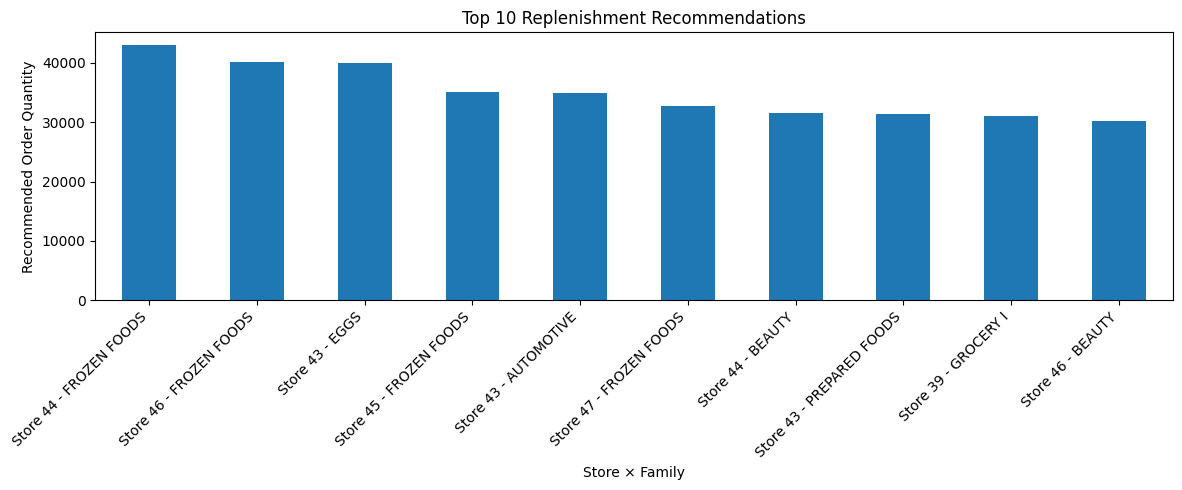

In [14]:
top_replenishment = priority_df.head(10).copy()

top_replenishment["series"] = (
    "Store "
    + top_replenishment["store_nbr"].astype(str)
    + " - "
    + top_replenishment["family"]
)

top_replenishment.plot(
    x="series",
    y="recommended_order_qty",
    kind="bar",
    figsize=(12, 5),
    legend=False,
    title="Top 10 Replenishment Recommendations"
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Recommended Order Quantity")
plt.xlabel("Store × Family")
plt.tight_layout()
plt.show()

## 7. Save Replenishment Results

The replenishment analysis results are saved for downstream use in the application and final project outputs.

In [15]:
# Save the complete replenishment results
replenishment_path = outputs_path / "replenishment_recommendations.csv"

priority_df.to_csv(
    replenishment_path,
    index=False
)

print("Replenishment results saved successfully")
print("Path:", replenishment_path)
print("Rows:", len(priority_df))

Replenishment results saved successfully
Path: D:\retail-demand-forecasting\outputs\replenishment_recommendations.csv
Rows: 1728


## 8. Final Validation

The final replenishment results are checked for completeness, missing values, negative quantities, and duplicate Store × Family combinations.

In [16]:
print("Rows:", len(priority_df))
print("Missing values:", priority_df.isna().sum().sum())
print(
    "Negative order quantities:",
    (priority_df["recommended_order_qty"] < 0).sum()
)
print(
    "Duplicate Store × Family rows:",
    priority_df.duplicated(
        subset=["store_nbr", "family"]
    ).sum()
)
print(
    "Unique series:",
    priority_df[["store_nbr", "family"]].drop_duplicates().shape[0]
)

Rows: 1728
Missing values: 0
Negative order quantities: 0
Duplicate Store × Family rows: 0
Unique series: 1728


## 9. Final Conclusion

The final DeepAR forecast was converted into Store × Family replenishment recommendations for the 15-day forecast horizon.

The replenishment analysis estimates expected demand during the assumed lead time and adds safety stock to calculate the recommended order quantity.

Because the original dataset does not contain inventory levels or supplier lead times, the recommendations are based on explicit assumptions and are intended to demonstrate the replenishment logic.

The final results cover 1,728 Store × Family series and passed all validation checks with no missing values, negative order quantities, or duplicate series.